In [5]:
import pandas as pd

file_path = "CIDDS-001-Sampled-Data.parquet"
df = pd.read_parquet(file_path)

df.head()

,Date first seen,Duration,Proto,Src IP Addr,Src Pt,Dst IP Addr,Dst Pt,Packets,Bytes,Flows,Flags,Tos,class,attackType,attackID,attackDescription
0,2017-03-17 14:18:05.000,0.004,TCP,192.168.220.16,34242,192.168.100.6,80.0,6,545,1,.AP.SF,0,attacker,dos,18,10000 connections on 192.168.100.6:80
1,2017-03-17 14:18:05.000,0.003,TCP,192.168.220.16,34242,192.168.100.6,80.0,6,545,1,.AP.SF,0,attacker,dos,18,10000 connections on 192.168.100.6:80
2,2017-03-17 14:18:05.001,0.001,TCP,192.168.100.6,80,192.168.220.16,34242.0,4,272,1,.A..SF,0,victim,dos,18,10000 connections on 192.168.100.6:80
3,2017-03-17 14:18:05.001,0.003,TCP,192.168.100.6,80,192.168.220.16,34242.0,4,272,1,.A..SF,0,victim,dos,18,10000 connections on 192.168.100.6:80
4,2017-03-17 14:18:05.002,0.005,TCP,192.168.220.16,34243,192.168.100.6,80.0,6,545,1,.AP.SF,0,attacker,dos,18,10000 connections on 192.168.100.6:80


/tmp/ipykernel_147625/3698831208.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='attackType', order=order, palette='viridis')


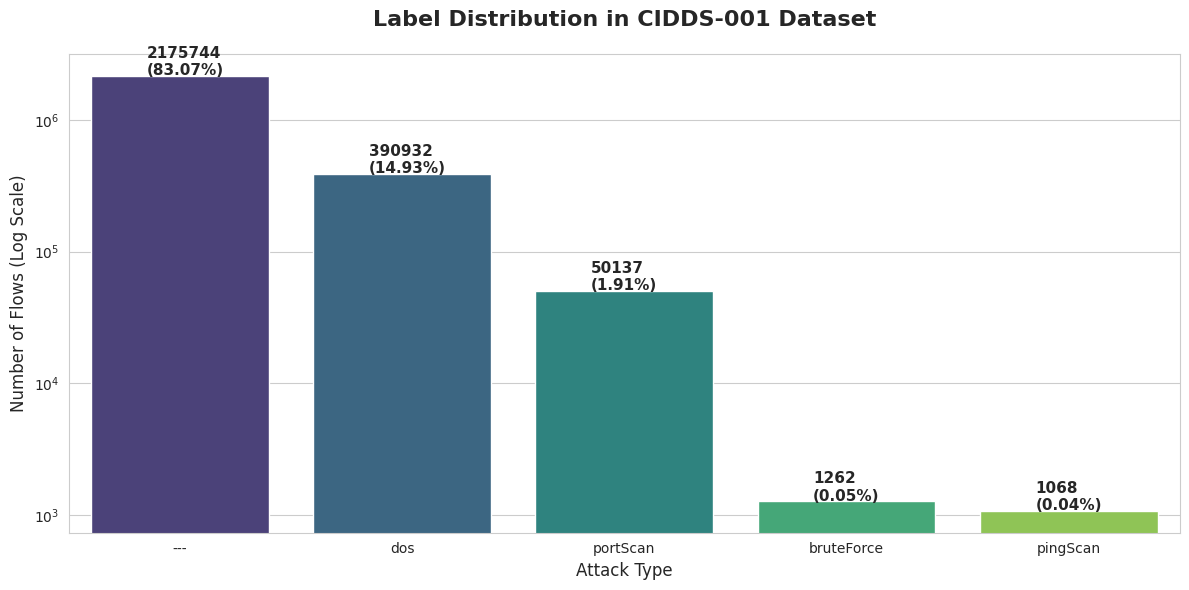

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
file_path = "CIDDS-001-Sampled-Data.parquet"
df = pd.read_parquet(file_path)

# 2. Thiết lập phong cách biểu đồ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Tạo biểu đồ cột (Count Plot)
# Chú ý: attackType là tên cột chứa nhãn trong CIDDS-001
order = df['attackType'].value_counts().index
ax = sns.countplot(data=df, x='attackType', order=order, palette='viridis')

# 4. Thêm số lượng và phần trăm lên đầu mỗi cột
total = len(df)
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (p.get_height() * 0.01)
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), size=11, fontweight='bold')

# 5. Tùy chỉnh tiêu đề và nhãn
plt.title('Label Distribution in CIDDS-001 Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Flows (Log Scale)', fontsize=12)

# Sử dụng Log Scale vì sự chênh lệch giữa Benign và PingScan là quá lớn
plt.yscale('log') 

plt.tight_layout()

# 6. Lưu ảnh để chèn vào LaTeX
plt.savefig('label_distribution.png', dpi=300)
plt.show()

In [6]:
label_counts = df['attackType'].value_counts()
label_proportions = df['attackType'].value_counts(normalize=True) * 100

# 3. Tạo bảng thống kê chi tiết
data_summary = pd.DataFrame({
    'Số lượng mẫu': label_counts,
    'Tỷ lệ (%)': label_proportions
})

print("--- THỐNG KÊ NHÃN DỮ LIỆU (TARGET ATTACK TYPE) ---")
print(data_summary)

# 4. Kiểm tra dữ liệu thiếu (nếu có)
print("\n--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---")
print(df.isnull().sum())

--- THỐNG KÊ NHÃN DỮ LIỆU (TARGET ATTACK TYPE) ---
            Số lượng mẫu  Tỷ lệ (%)
attackType                         
---              2175744  83.070837
dos               390932  14.925951
portScan           50137   1.914252
bruteForce          1262   0.048184
pingScan            1068   0.040777

--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---
Date first seen      0
Duration             0
Proto                0
Src IP Addr          0
Src Pt               0
Dst IP Addr          0
Dst Pt               0
Packets              0
Bytes                0
Flows                0
Flags                0
Tos                  0
class                0
attackType           0
attackID             0
attackDescription    0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder

df = pd.read_parquet("CIDDS-001-Sampled-Data.parquet")

print("1. Đang làm sạch cột 'Bytes'...")
def clean_bytes(val):
    if pd.isna(val):
        return 0.0
    val = str(val).strip().upper()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val)

df['Bytes'] = df['Bytes'].apply(clean_bytes)

# Khai báo features (X) và target (y)
features = [
    'Src IP Addr', 'Src Pt', 'Dst IP Addr', 'Dst Pt', 
    'Proto', 'Flags', 'Duration', 'Bytes', 'Packets'
]
X = df[features].copy()
y = df['attackType'].copy()

print("2. Đang chia tập Train/Test (Split 70/30)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("3. Đang mã hóa Đặc trưng (Frequency) và Nhãn (Label)...")
# A. Frequency Encoding cho X (Đầu vào)
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in cat_cols:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq).fillna(0)
    X_test[col] = X_test[col].map(freq).fillna(0)

# Ép kiểu float chuẩn bị cho Scaling
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# B. Label Encoding cho y (Đầu ra)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("4. Đang chuẩn hóa dữ liệu (Min-Max Scaling 0-1)...")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


1. Đang làm sạch cột 'Bytes'...
2. Đang chia tập Train/Test (Split 70/30)...
            Src IP Addr  Src Pt     Dst IP Addr   Dst Pt  Proto   Flags  \
2090353       11046_155     443  192.168.220.10  39971.0  TCP    .AP...   
1052605   OPENSTACK_NET   61370      EXT_SERVER   8000.0  TCP    .AP.SF   
1535395  192.168.220.16   48399   192.168.100.6     80.0  TCP    .AP.SF   
717520   192.168.220.14   35683        10063_33     80.0  TCP    .A....   
1971951  192.168.220.16   54828   192.168.100.6     80.0  TCP    .AP.SF   

         Duration   Bytes  Packets  
2090353     1.949  1003.0       10  
1052605     0.055   589.0        6  
1535395     0.005   479.0        5  
717520      0.000    66.0        1  
1971951     0.004   479.0        5  
3. Đang mã hóa Đặc trưng (Frequency) và Nhãn (Label)...
4. Đang chuẩn hóa dữ liệu (Min-Max Scaling 0-1)...
[[2.32904629e-03 6.75974670e-03 1.36377219e-01 ... 7.09772884e-05
  1.88880289e-06 4.42334346e-05]
 [3.32360043e-02 9.36446174e-01 2.19772623e-

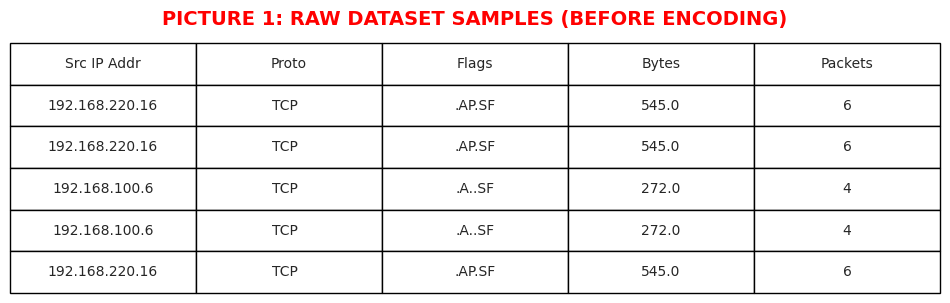

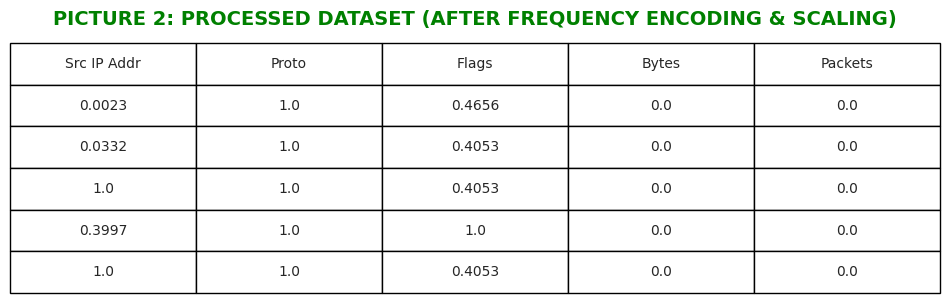

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử X là dataframe ban đầu (trước khi map frequency) 
# và X_train_scaled là mảng sau khi đã scale.
# Ta sẽ lấy 5 dòng đầu tiên để minh họa

# 1. Tạo bảng "BEFORE" (Dữ liệu thô)
cols_to_show = ['Src IP Addr', 'Proto', 'Flags', 'Bytes', 'Packets']
df_before = df[cols_to_show].head(5)

# 2. Tạo bảng "AFTER" (Dữ liệu sau khi mã hóa & scale)
# Lấy 5 dòng đầu từ X_train_scaled và chuyển về DataFrame để vẽ
df_after = pd.DataFrame(X_train_scaled[:5, :], columns=features)[cols_to_show]

# Vẽ 2 bức ảnh
def save_table_img(df, title, filename, color):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20, color=color)
    table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.5)
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

# Tạo ảnh 1: Trước mã hóa
save_table_img(df_before, "PICTURE 1: RAW DATASET SAMPLES (BEFORE ENCODING)", "before_encoding.png", "red")

# Tạo ảnh 2: Sau mã hóa
save_table_img(df_after.round(4), "PICTURE 2: PROCESSED DATASET (AFTER FREQUENCY ENCODING & SCALING)", "after_encoding.png", "green")

5. Đang huấn luyện mô hình Random Forest (weight=None)...
6. Đang xuất ảnh: Feature Importance...


/tmp/ipykernel_147625/1910624726.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')


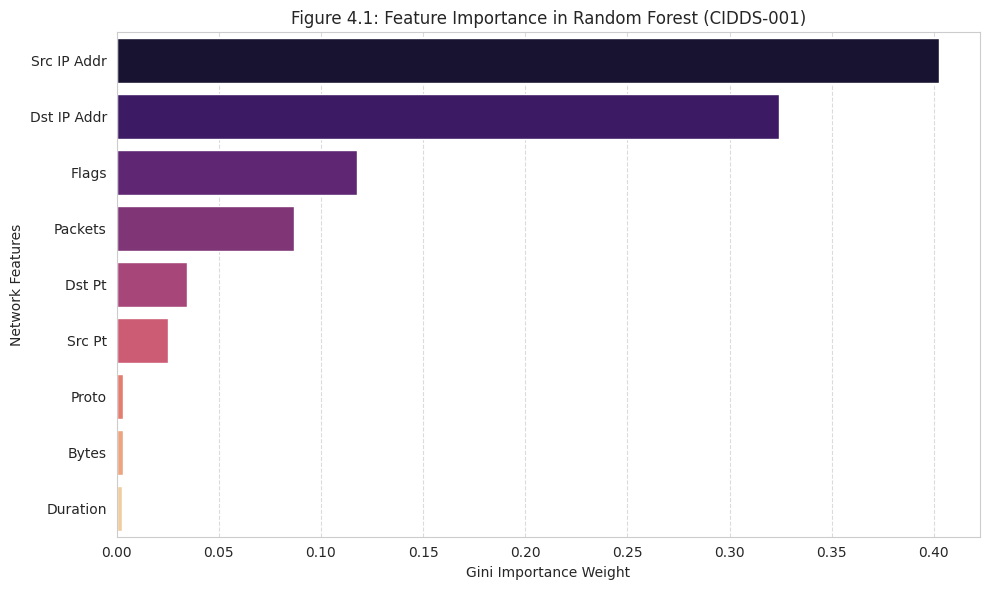

7. Đang xuất ảnh: F1-Score per Class...


/tmp/ipykernel_147625/1910624726.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='F1-Score', data=f1_df, palette='viridis')


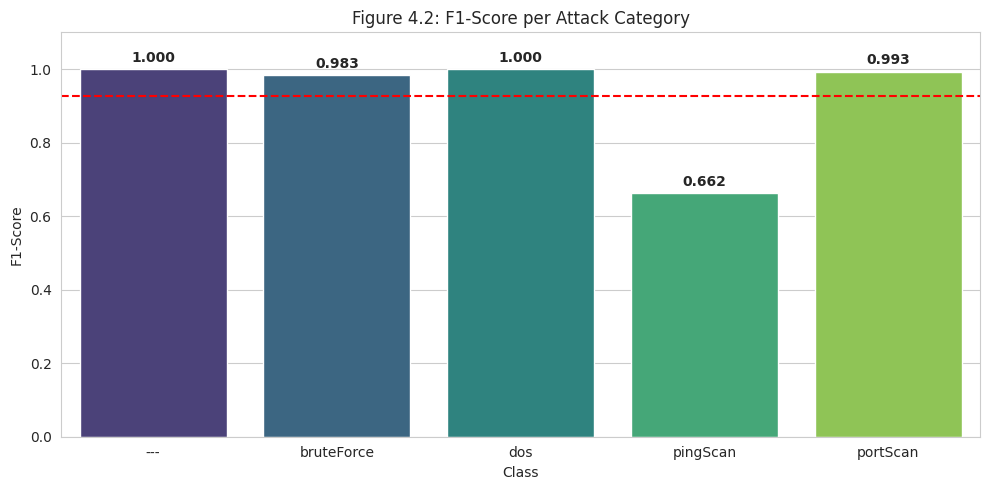

8. Đang xuất ảnh: Confusion Matrix...


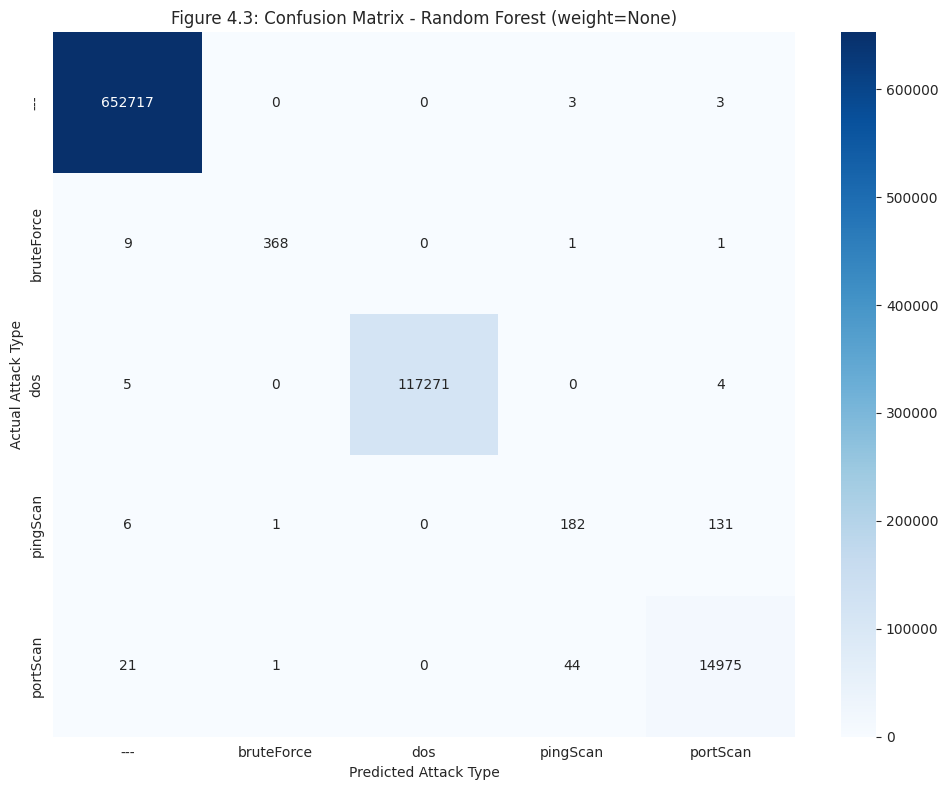


DIAGNOSIS REPORT: PINGSCAN CLASS
Actual Samples: 320
Correctly Identified (TP): 182
Missed (FN): 138


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# --- GIAI ĐOẠN 5: HUẤN LUYỆN RF (WEIGHT = NONE) ---
print("5. Đang huấn luyện mô hình Random Forest (weight=None)...")
model_rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_scaled, y_train)

# --- GIAI ĐOẠN 6: TRỰC QUAN HÓA FEATURE IMPORTANCE ---
print("6. Đang xuất ảnh: Feature Importance...")
importances = model_rf.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Figure 4.1: Feature Importance in Random Forest (CIDDS-001)')
plt.xlabel('Gini Importance Weight')
plt.ylabel('Network Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300) # Lưu ảnh cho Chapter 4
plt.show()

# --- GIAI ĐOẠN 7: ĐÁNH GIÁ VÀ XUẤT ẢNH F1-SCORE TỪNG LỚP ---
print("7. Đang xuất ảnh: F1-Score per Class...")
y_pred = model_rf.predict(X_test_scaled)
classes = label_encoder.classes_
report_dict = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

# Tạo DataFrame cho F1-score
f1_data = {cls: report_dict[cls]['f1-score'] for cls in classes}
f1_df = pd.DataFrame(list(f1_data.items()), columns=['Class', 'F1-Score'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='F1-Score', data=f1_df, palette='viridis')
plt.axhline(y=np.mean(f1_df['F1-Score']), color='red', linestyle='--', label='Average F1')
plt.title('Figure 4.2: F1-Score per Attack Category')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_df['F1-Score']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('f1_score_per_class.png', dpi=300)
plt.show()

# --- GIAI ĐOẠN 8: XUẤT ẢNH CONFUSION MATRIX ---
print("8. Đang xuất ảnh: Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Figure 4.3: Confusion Matrix - Random Forest (weight=None)')
plt.ylabel('Actual Attack Type')
plt.xlabel('Predicted Attack Type')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# --- BÁO CÁO "BẮT BỆNH" PINGSCAN (In ra console) ---
try:
    ping_idx = np.where(classes == 'pingScan')[0][0]
    print("\n" + "="*40)
    print("DIAGNOSIS REPORT: PINGSCAN CLASS")
    print(f"Actual Samples: {sum(cm[ping_idx, :])}")
    print(f"Correctly Identified (TP): {cm[ping_idx, ping_idx]}")
    print(f"Missed (FN): {sum(cm[ping_idx, :]) - cm[ping_idx, ping_idx]}")
    print("="*40)
except:
    pass

5. Đang huấn luyện mô hình Random Forest (weight='balanced')...
6. Đang xuất ảnh: Feature Importance (Balanced)...


/tmp/ipykernel_147625/3443332594.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


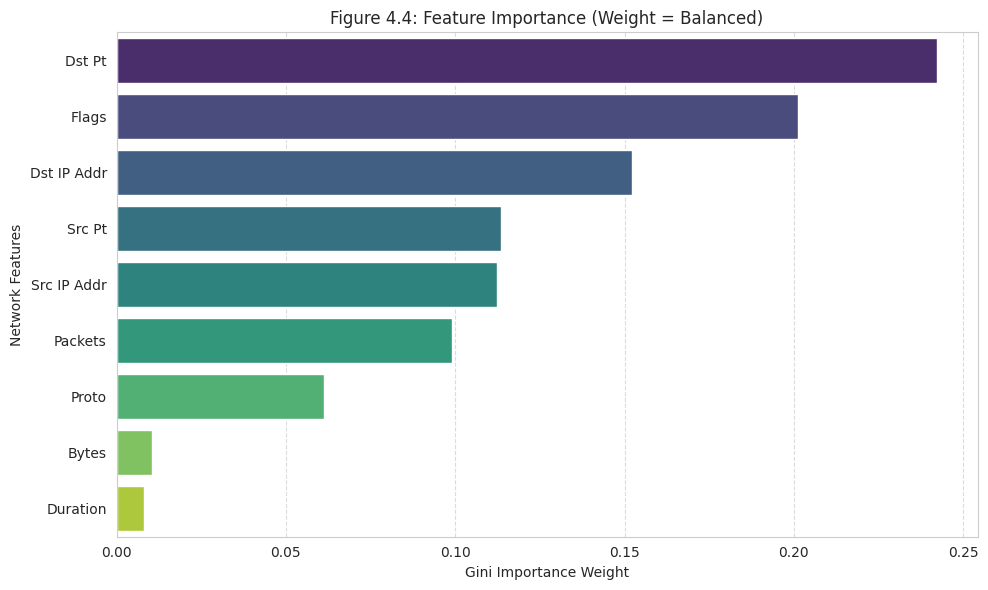

7. Đang xuất ảnh: F1-Score per Class (Balanced)...


/tmp/ipykernel_147625/3443332594.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='F1-Score', data=f1_df_bal, palette='magma')


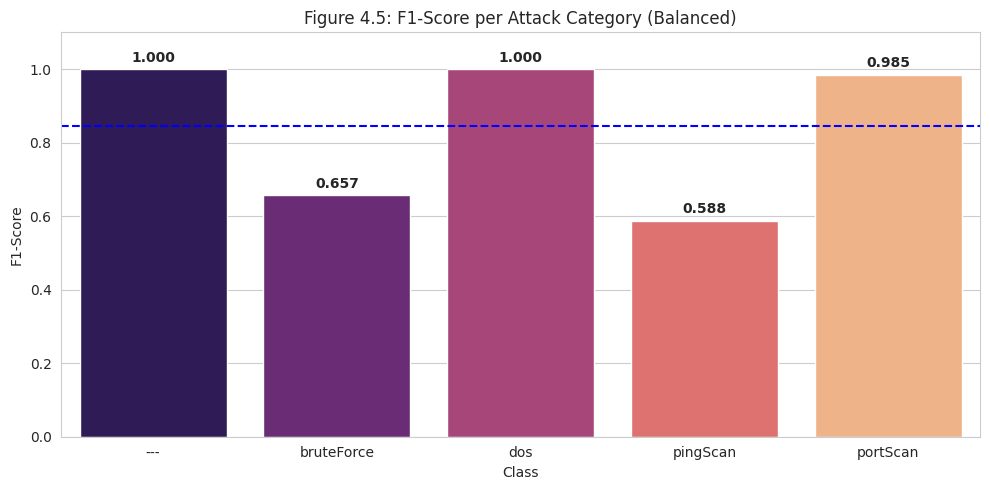

8. Đang xuất ảnh: Confusion Matrix (Balanced)...


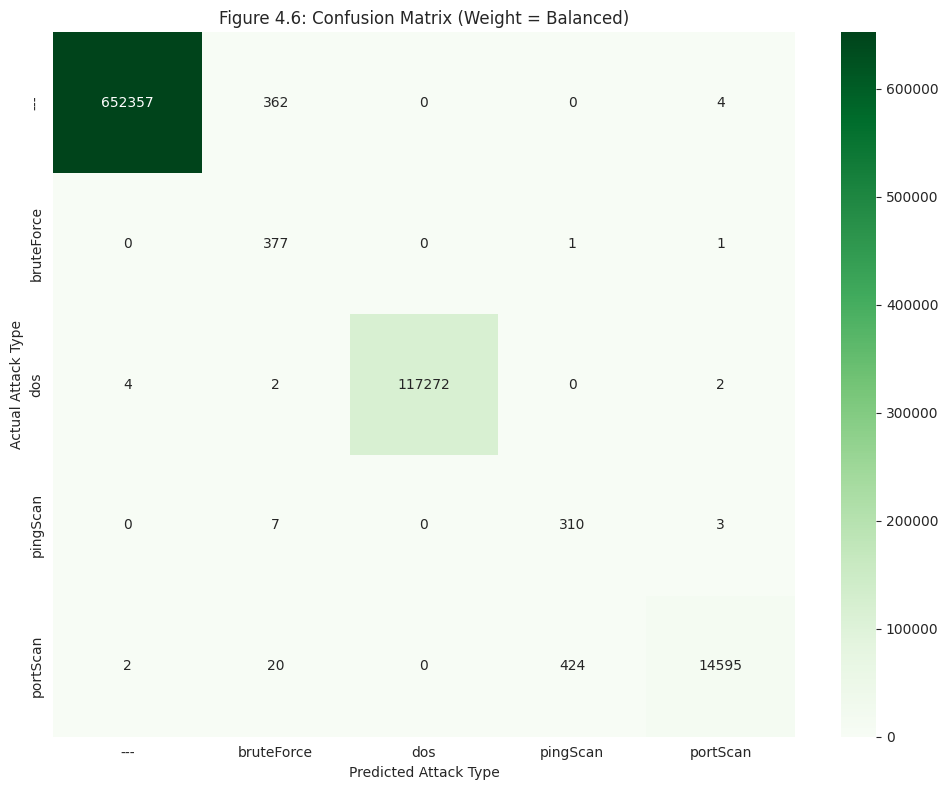


--- KẾT QUẢ TỔNG HỢP (BALANCED) ---
Macro Average F1-score: 0.8459


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("5. Đang huấn luyện mô hình Random Forest (weight='balanced')...")
# Khởi tạo RF với tham số balanced để so sánh
model_rf_bal = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', # Kích hoạt tính năng cân bằng trọng số
    random_state=42,
    n_jobs=-1
)

# Huấn luyện trên dữ liệu đã chuẩn hóa
model_rf_bal.fit(X_train_scaled, y_train)

# --- 1. XUẤT ẢNH FEATURE IMPORTANCE (BALANCED) ---
print("6. Đang xuất ảnh: Feature Importance (Balanced)...")
importances = model_rf_bal.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Figure 4.4: Feature Importance (Weight = Balanced)')
plt.xlabel('Gini Importance Weight')
plt.ylabel('Network Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance_balanced.png', dpi=300) # Lưu tên file khác
plt.show()

# --- 2. DỰ ĐOÁN VÀ XUẤT ẢNH F1-SCORE TỪNG LỚP (BALANCED) ---
print("7. Đang xuất ảnh: F1-Score per Class (Balanced)...")
y_pred_bal = model_rf_bal.predict(X_test_scaled)
classes = label_encoder.classes_
report_dict_bal = classification_report(y_test, y_pred_bal, target_names=classes, output_dict=True)

f1_data_bal = {cls: report_dict_bal[cls]['f1-score'] for cls in classes}
f1_df_bal = pd.DataFrame(list(f1_data_bal.items()), columns=['Class', 'F1-Score'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Class', y='F1-Score', data=f1_df_bal, palette='magma')
plt.axhline(y=np.mean(f1_df_bal['F1-Score']), color='blue', linestyle='--', label='Average F1')
plt.title('Figure 4.5: F1-Score per Attack Category (Balanced)')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_df_bal['F1-Score']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('f1_score_per_class_balanced.png', dpi=300)
plt.show()

# --- 3. XUẤT ẢNH CONFUSION MATRIX (BALANCED) ---
print("8. Đang xuất ảnh: Confusion Matrix (Balanced)...")
cm_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Figure 4.6: Confusion Matrix (Weight = Balanced)')
plt.ylabel('Actual Attack Type')
plt.xlabel('Predicted Attack Type')
plt.tight_layout()
plt.savefig('confusion_matrix_balanced.png', dpi=300)
plt.show()

# In kết quả tổng hợp để so sánh nhanh
print("\n--- KẾT QUẢ TỔNG HỢP (BALANCED) ---")
f1_macro_bal = f1_score(y_test, y_pred_bal, average='macro')
print(f"Macro Average F1-score: {f1_macro_bal:.4f}")

/tmp/ipykernel_147625/68385693.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Training Time (s)', data=df_time, ax=ax[0], palette='coolwarm')
/tmp/ipykernel_147625/68385693.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Inference Time (s)', data=df_time, ax=ax[1], palette='viridis')


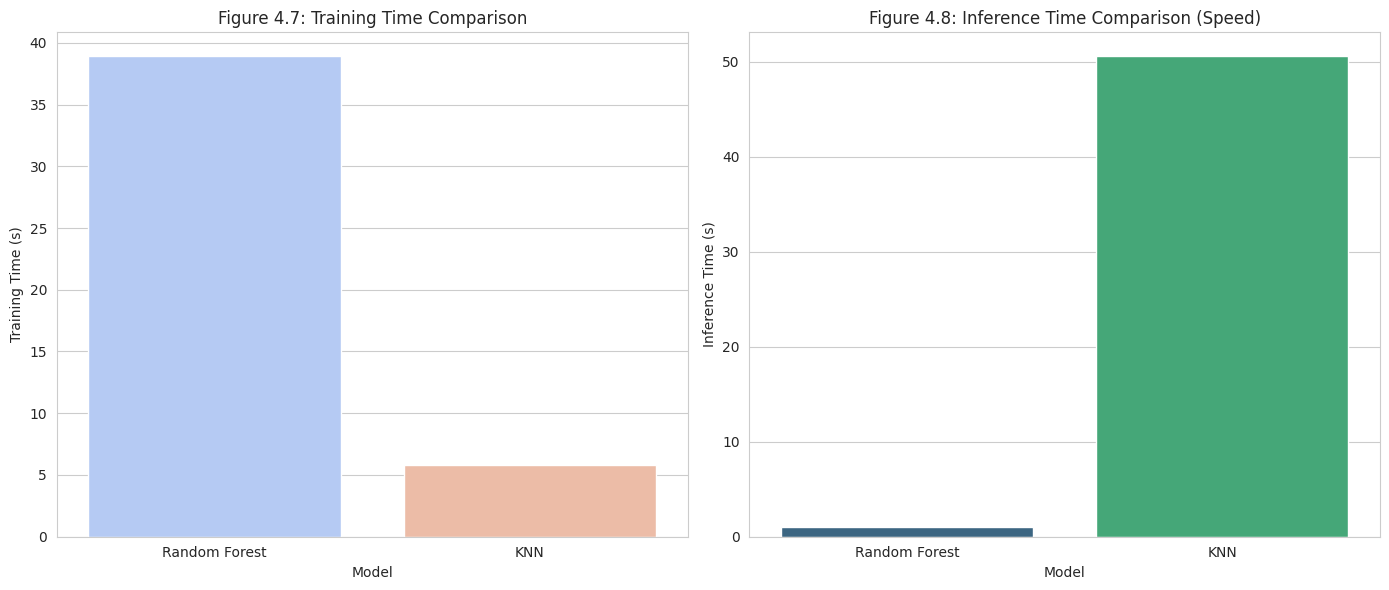


--- BẢNG SO SÁNH THỜI GIAN CHI TIẾT ---
        Model  Training Time (s)  Inference Time (s)
Random Forest          38.900171            1.019468
          KNN           5.813216           50.579456


In [31]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Khởi tạo 2 model với cấu hình bạn đã chọn
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results_time = []

for name, model in models.items():
    # 1. Đo thời gian Huấn luyện (Training)
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()
    train_time = end_train - start_train
    
    # 2. Đo thời gian Dự đoán (Inference) trên tập Test
    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    end_pred = time.time()
    pred_time = end_pred - start_pred
    
    results_time.append({
        'Model': name,
        'Training Time (s)': train_time,
        'Inference Time (s)': pred_time
    })

# Chuyển thành DataFrame để vẽ ảnh
df_time = pd.DataFrame(results_time)

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ thời gian huấn luyện
sns.barplot(x='Model', y='Training Time (s)', data=df_time, ax=ax[0], palette='coolwarm')
ax[0].set_title('Figure 4.7: Training Time Comparison')

# Biểu đồ thời gian dự đoán
sns.barplot(x='Model', y='Inference Time (s)', data=df_time, ax=ax[1], palette='viridis')
ax[1].set_title('Figure 4.8: Inference Time Comparison (Speed)')

plt.tight_layout()
plt.savefig('model_speed_comparison.png', dpi=300)
plt.show()

print("\n--- BẢNG SO SÁNH THỜI GIAN CHI TIẾT ---")
print(df_time.to_string(index=False))

In [11]:
from sklearn.metrics import f1_score
import pandas as pd

# 1. Định nghĩa bộ đặc trưng mới (ĐÃ LOẠI BỎ IP)
features_no_ip = [
    'Src Pt', 'Dst Pt', 'Proto', 'Flags', 
    'Duration', 'Bytes', 'Packets'
]

# Chuẩn bị dữ liệu (Lấy từ X_train_scaled/X_test_scaled nhưng bỏ cột IP)
# Lưu ý: Cột 0 và 2 trong 'features' cũ là Src IP và Dst IP
X_train_no_ip = np.delete(X_train_scaled, [0, 2], axis=1)
X_test_no_ip = np.delete(X_test_scaled, [0, 2], axis=1)

# 2. Trường hợp A: Không có Balanced (Default)
model_no_bal = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_no_bal.fit(X_train_no_ip, y_train)
y_pred_no_bal = model_no_bal.predict(X_test_no_ip)
f1_no_bal = f1_score(y_test, y_pred_no_bal, average='macro')

# 3. Trường hợp B: Có Balanced
model_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_bal.fit(X_train_no_ip, y_train)
y_pred_bal = model_bal.predict(X_test_no_ip)
f1_bal = f1_score(y_test, y_pred_bal, average='macro')

print("--- KẾT QUẢ KIỂM CHỨNG (SAU KHI BỎ IP) ---")
print(f"Macro F1 (KHÔNG Balanced): {f1_no_bal:.4f}")
print(f"Macro F1 (CÓ Balanced):    {f1_bal:.4f}")

--- KẾT QUẢ KIỂM CHỨNG (SAU KHI BỎ IP) ---
Macro F1 (KHÔNG Balanced): 0.8641
Macro F1 (CÓ Balanced):    0.7188


1. Đang tải và làm sạch cột 'Bytes'...
2. Đang chia tập Train/Test (Split 70/30)...
3. Đang mã hóa Đặc trưng (Frequency) và Nhãn (Label)...
4. Đang chuẩn hóa dữ liệu (Min-Max Scaling 0-1)...
5. Đang huấn luyện mô hình KNN...
6. Đang dự đoán và đánh giá (Lưu ý: KNN có thể mất chút thời gian để dự đoán)...

[KẾT QUẢ TỔNG THỂ KNN] MACRO F1-SCORE: 0.9152969073129444

--- BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

         ---       1.00      1.00      1.00    652723
  bruteForce       0.98      0.97      0.98       379
         dos       1.00      1.00      1.00    117280
    pingScan       0.59      0.63      0.61       320
    portScan       0.99      0.99      0.99     15041

    accuracy                           1.00    785743
   macro avg       0.91      0.92      0.92    785743
weighted avg       1.00      1.00      1.00    785743


7. Đang vẽ Ma trận nhầm lẫn...


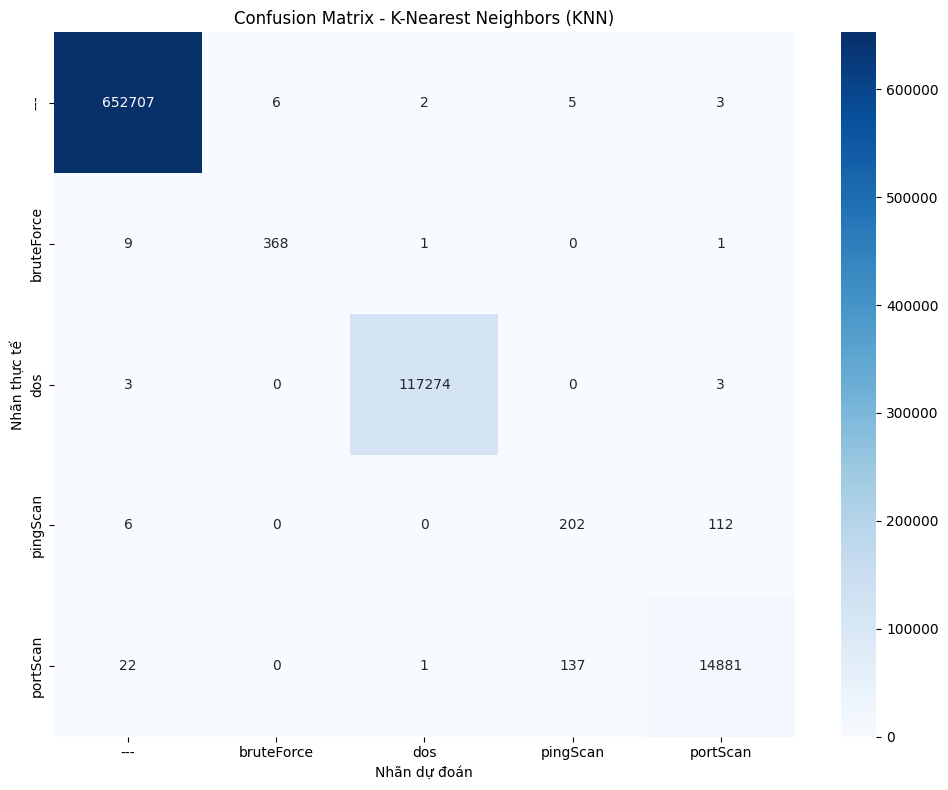